# 📐 Análise de Complexidade de Algoritmos
### COMP0496 — Algoritmos e Estruturas de Dados
**Universidade Federal de Sergipe — DCOMP**

---

**Duração estimada:** 100 minutos

| Seção | Tópico | Tempo |
|:---:|---|:---:|
| 1 | Revisão: notação assintótica e contagem de operações | 10 min |
| 2 | Análise de algoritmos iterativos | 25 min |
| 3 | Análise de algoritmos recursivos | 25 min |
| 4 | Teorema Mestre | 20 min |
| 5 | Exercícios de fixação | 20 min |

**Objetivo:** Praticar a análise de complexidade de tempo de algoritmos iterativos e recursivos, aplicando notação assintótica e o Teorema Mestre.

---
## 🔧 Setup inicial

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from math import log2, ceil, floor

# Função auxiliar para medir tempo de execução
def medir_tempo(func, *args, repeticoes=5):
    """Mede o tempo médio de execução de uma função."""
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        resultado = func(*args)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return np.mean(tempos), resultado

# Função para plotar complexidades
def plotar_complexidades(ns, tempos_dict, titulo="Comparação de Complexidades"):
    """Plota os tempos de execução medidos."""
    plt.figure(figsize=(10, 5))
    for nome, tempos in tempos_dict.items():
        plt.plot(ns, tempos, 'o-', label=nome, linewidth=2, markersize=4)
    plt.xlabel('Tamanho da entrada (n)', fontsize=12)
    plt.ylabel('Tempo (s)', fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ Setup concluído!")

✅ Setup concluído!


---
## Seção 1 — Revisão: Notação Assintótica e Contagem de Operações (10 min)

### Recordando as notações

Seja $f(n)$ a função que descreve o número de operações de um algoritmo em função do tamanho da entrada $n$:

| Notação | Significado | Intuição |
|:---:|---|---|
| $O(g(n))$ | Limite superior assintótico | $f$ cresce **no máximo** tão rápido quanto $g$ |
| $\Omega(g(n))$ | Limite inferior assintótico | $f$ cresce **pelo menos** tão rápido quanto $g$ |
| $\Theta(g(n))$ | Limite justo (tight) | $f$ cresce **na mesma taxa** que $g$ |

### Definição formal de $O(g(n))$

$$f(n) \in O(g(n)) \iff \exists\, c > 0,\; n_0 > 0 \text{ tais que } 0 \le f(n) \le c \cdot g(n),\; \forall\, n \ge n_0$$

### Hierarquia de crescimento

$$O(1) \subset O(\log n) \subset O(n) \subset O(n \log n) \subset O(n^2) \subset O(n^3) \subset O(2^n) \subset O(n!)$$

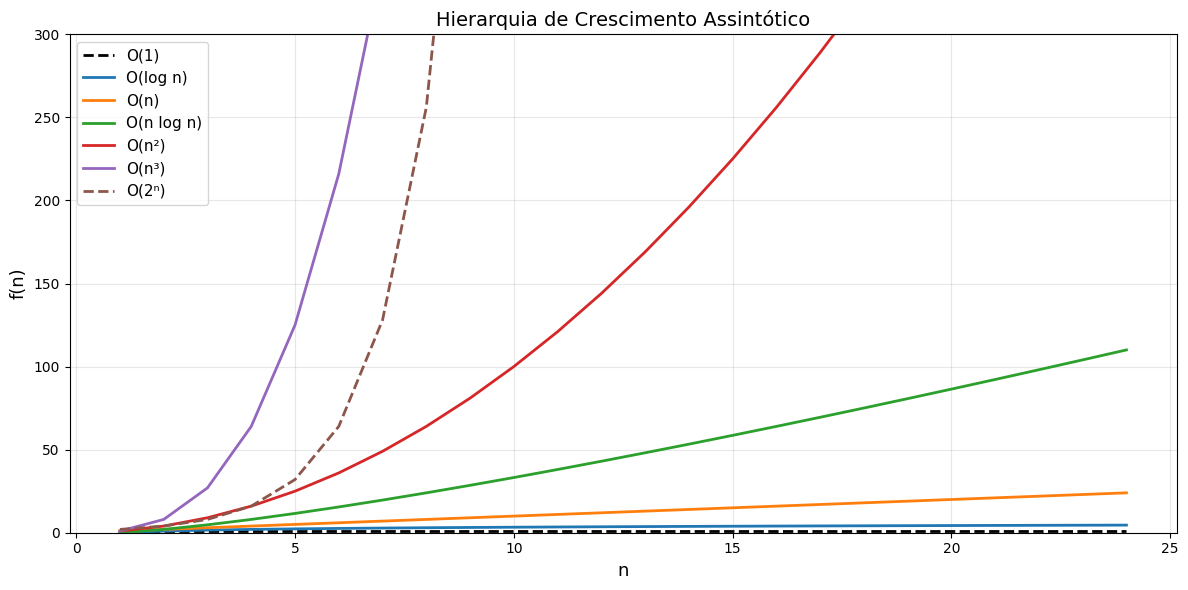

In [ ]:
# Visualização da hierarquia de crescimento
n = np.arange(1, 25)

plt.figure(figsize=(12, 6))
plt.plot(n, np.ones_like(n), 'k--', label='O(1)', linewidth=2)
plt.plot(n, np.log2(n), label='O(log n)', linewidth=2)
plt.plot(n, n, label='O(n)', linewidth=2)
plt.plot(n, n * np.log2(n), label='O(n log n)', linewidth=2)
plt.plot(n, n**2, label='O(n²)', linewidth=2)
plt.plot(n, n**3, label='O(n³)', linewidth=2)
plt.plot(n, 2.0**n, label='O(2ⁿ)', linewidth=2, linestyle='--')

plt.ylim(0, 300)
plt.xlabel('n', fontsize=13)
plt.ylabel('f(n)', fontsize=13)
plt.title('Hierarquia de Crescimento Assintótico', fontsize=14)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Regras práticas para contagem de operações

1. **Operações simples** (atribuição, comparação, aritmética): $O(1)$
2. **Sequência** de blocos: soma dos custos → domina o maior
3. **Laço `for` de 1 a $n$**: multiplica o custo do corpo por $n$
4. **Laços aninhados**: multiplica os limites dos laços
5. **Chamada recursiva**: requer equação de recorrência

---
## Seção 2 — Análise de Algoritmos Iterativos (25 min)

Vamos analisar algoritmos iterativos contando o número de operações dominantes.

### Exemplo 1: Busca Linear

```
BUSCA-LINEAR(A, n, x)
  para i ← 1 até n faça        // executa n vezes (pior caso)
      se A[i] == x então        //   1 comparação
          retorne i             //   (saída antecipada)
  retorne -1
```

**Análise:**
- Melhor caso: $\Omega(1)$ — o elemento está na primeira posição.
- Pior caso: $O(n)$ — o elemento não está no vetor.
- Caso médio: $\Theta(n)$ — em média, percorre metade do vetor.

In [ ]:
def busca_linear(A, x):
    """Busca linear com contador de comparações."""
    comparacoes = 0
    for i in range(len(A)):
        comparacoes += 1
        if A[i] == x:
            return i, comparacoes
    return -1, comparacoes

# Demonstração: pior caso (elemento ausente)
tamanhos = [100, 500, 1000, 5000, 10000]
print("Busca Linear — Pior Caso (elemento ausente)")
print(f"{'n':>8} | {'Comparações':>12} | {'Razão comp/n':>12}")
print("-" * 40)
for n in tamanhos:
    A = list(range(n))
    _, comp = busca_linear(A, -1)  # -1 não está no vetor
    print(f"{n:>8} | {comp:>12} | {comp/n:>12.2f}")

print("\n→ A razão comparações/n permanece constante ≈ 1 → confirma O(n)")

Busca Linear — Pior Caso (elemento ausente)
       n |  Comparações | Razão comp/n
----------------------------------------
     100 |          100 |         1.00
     500 |          500 |         1.00
    1000 |         1000 |         1.00
    5000 |         5000 |         1.00
   10000 |        10000 |         1.00

→ A razão comparações/n permanece constante ≈ 1 → confirma O(n)


### Exemplo 2: Bubble Sort

```
BUBBLE-SORT(A, n)
  para i ← 1 até n-1 faça            // n-1 iterações
      para j ← 1 até n-i faça        //   n-i iterações
          se A[j] > A[j+1] então      //     1 comparação
              trocar A[j] ↔ A[j+1]   //     O(1)
```

**Contagem de comparações:**

$$T(n) = \sum_{i=1}^{n-1} (n - i) = (n-1) + (n-2) + \cdots + 1 = \frac{n(n-1)}{2} = \Theta(n^2)$$

In [ ]:
def bubble_sort_contagem(A):
    """Bubble sort com contagem de comparações e trocas."""
    n = len(A)
    comparacoes = 0
    trocas = 0
    arr = A.copy()
    for i in range(n - 1):
        for j in range(n - 1 - i):
            comparacoes += 1
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                trocas += 1
    return arr, comparacoes, trocas

print("Bubble Sort — Contagem de operações")
print(f"{'n':>6} | {'Comparações':>12} | {'n(n-1)/2':>10} | {'Trocas':>8}")
print("-" * 48)
for n in [10, 50, 100, 500, 1000]:
    A = list(range(n, 0, -1))  # pior caso: ordem decrescente
    _, comp, trocas = bubble_sort_contagem(A)
    formula = n * (n - 1) // 2
    print(f"{n:>6} | {comp:>12} | {formula:>10} | {trocas:>8}")

print("\n→ Comparações = n(n-1)/2 exatamente → Θ(n²)")

Bubble Sort — Contagem de operações
     n |  Comparações |   n(n-1)/2 |   Trocas
------------------------------------------------
    10 |           45 |         45 |       45
    50 |         1225 |       1225 |     1225
   100 |         4950 |       4950 |     4950
   500 |       124750 |     124750 |   124750
  1000 |       499500 |     499500 |   499500

→ Comparações = n(n-1)/2 exatamente → Θ(n²)


### Exemplo 3: Laço com passo multiplicativo

```
MISTERIOSO(n)
  i ← 1
  enquanto i < n faça
      // operação O(1)
      i ← i * 2
```

**Análise:** O valor de `i` segue a sequência $1, 2, 4, 8, \ldots, 2^k$, onde $2^k \geq n$.

Logo, $k = \lceil \log_2 n \rceil$ → **$T(n) = \Theta(\log n)$**

In [ ]:
def misterioso(n):
    """Laço com passo multiplicativo."""
    i = 1
    iteracoes = 0
    while i < n:
        iteracoes += 1
        i *= 2
    return iteracoes

print("Laço multiplicativo — Contagem de iterações")
print(f"{'n':>10} | {'Iterações':>10} | {'⌈log₂(n)⌉':>10}")
print("-" * 38)
for n in [10, 100, 1000, 10_000, 100_000, 1_000_000]:
    iters = misterioso(n)
    log_n = ceil(log2(n))
    print(f"{n:>10} | {iters:>10} | {log_n:>10}")

print("\n→ Iterações = ⌈log₂(n)⌉ → Θ(log n)")

Laço multiplicativo — Contagem de iterações
         n |  Iterações |  ⌈log₂(n)⌉
--------------------------------------
        10 |          4 |          4
       100 |          7 |          7
      1000 |         10 |         10
     10000 |         14 |         14
    100000 |         17 |         17
   1000000 |         20 |         20

→ Iterações = ⌈log₂(n)⌉ → Θ(log n)


### Exemplo 4: Laços aninhados com dependência

```
SOMA-PARCIAL(n)
  s ← 0
  para i ← 1 até n faça
      para j ← 1 até i faça
          s ← s + 1
  retorne s
```

**Contagem:**

$$T(n) = \sum_{i=1}^{n} i = \frac{n(n+1)}{2} = \Theta(n^2)$$

> ⚠️ **Atenção:** Nem todo laço aninhado é $\Theta(n^2)$! É preciso analisar os limites cuidadosamente.

In [ ]:
def soma_parcial(n):
    s = 0
    ops = 0
    for i in range(1, n + 1):
        for j in range(1, i + 1):
            s += 1
            ops += 1
    return s, ops

print("Laço aninhado com dependência")
print(f"{'n':>6} | {'Operações':>10} | {'n(n+1)/2':>10} | {'Razão ops/n²':>12}")
print("-" * 48)
for n in [10, 50, 100, 500, 1000]:
    _, ops = soma_parcial(n)
    formula = n * (n + 1) // 2
    print(f"{n:>6} | {ops:>10} | {formula:>10} | {ops / n**2:>12.4f}")

print("\n→ Razão ops/n² converge para 0.5 → Θ(n²)")

Laço aninhado com dependência
     n |  Operações |   n(n+1)/2 | Razão ops/n²
------------------------------------------------
    10 |         55 |         55 |       0.5500
    50 |       1275 |       1275 |       0.5100
   100 |       5050 |       5050 |       0.5050
   500 |     125250 |     125250 |       0.5010
  1000 |     500500 |     500500 |       0.5005

→ Razão ops/n² converge para 0.5 → Θ(n²)


### ✏️ Exercício 1 — Análise de laço iterativo

Analise o seguinte algoritmo e determine sua complexidade assintótica:

```
ALGORITMO-A(n)
  s ← 0
  para i ← 1 até n faça
      j ← i
      enquanto j > 0 faça
          s ← s + j
          j ← j ÷ 2       (divisão inteira)
  retorne s
```

**Tarefas:**
1. Quantas vezes o laço `enquanto` executa para um dado valor de `i`?
R = log 2(i) + 1

2. Escreva a soma total de operações $T(n)$.
R = T(n) = (log2(1)+1) + (log2(2)+1) + ... + (log2(n)+1)

3. Determine $T(n)$ em notação $\Theta$.
R = theta(n log n)

In [ ]:
# Implemente o algoritmo com contagem e verifique sua análise!

def algoritmo_a(n):
    s = 0
    ops = 0
    for i in range(1, n + 1):
        j = i
        while j > 0:
            s += j
            j = j // 2
            ops += 1
    return s, ops

# Complete a tabela para validar sua resposta
print(f"{'n':>8} | {'Operações':>10} | {'Razão ops/(n·log n)':>20}")
print("-" * 45)
for n in [100, 500, 1000, 5000, 10000]:
    _, ops = algoritmo_a(n)
    razao = ops / (n * log2(n)) if n > 1 else 0
    print(f"{n:>8} | {ops:>10} | {razao:>20.4f}")

print("\n🤔 A razão converge? Para qual valor? O que isso diz sobre T(n)?")

       n |  Operações |  Razão ops/(n·log n)
---------------------------------------------
     100 |        580 |               0.8730
     500 |       3998 |               0.8918
    1000 |       8987 |               0.9018
    5000 |      56822 |               0.9249
   10000 |     123631 |               0.9304

🤔 A razão converge? Para qual valor? O que isso diz sobre T(n)?


<details>
<summary>💡 Clique para ver a solução</summary>

Para cada $i$, o laço `enquanto` executa $\lfloor\log_2 i\rfloor + 1$ vezes (dividimos $i$ por 2 até chegar a 0).

$$T(n) = \sum_{i=1}^{n} (\lfloor\log_2 i\rfloor + 1) \approx \sum_{i=1}^{n} \log_2 i = \log_2(n!) \approx n\log_2 n - n\log_2 e$$

Portanto, $T(n) = \Theta(n \log n)$.

</details>

### ✏️ Exercício 2 — Análise de laço com passo variável

Analise este algoritmo:

```
ALGORITMO-B(n)
  s ← 0
  i ← n
  enquanto i ≥ 1 faça
      para j ← 1 até i faça
          s ← s + 1
      i ← ⌊i / 2⌋
  retorne s
```

**Tarefas:**
1. Liste os valores que `i` assume ao longo da execução.
R = n, n/2, n/4, n/8, ..., 1.

2. Escreva $T(n)$ como uma soma.
R = n, n/2, n/4, n/8, ..., 1 (considerando divisão inteira).

3. Determine a complexidade assintótica.
R = Theta(n)

In [ ]:
def algoritmo_b(n):
    s = 0
    ops = 0
    i = n
    while i >= 1:
        for j in range(1, i + 1):
            s += 1
            ops += 1
        i = i // 2
    return s, ops

# Verifique sua resposta
print(f"{'n':>8} | {'Operações':>10} | {'Razão ops/n':>12}")
print("-" * 36)
for n in [100, 500, 1000, 5000, 10000, 50000]:
    _, ops = algoritmo_b(n)
    print(f"{n:>8} | {ops:>10} | {ops/n:>12.4f}")

print("\n🤔 A razão converge? O que T(n) parece ser?")

       n |  Operações |  Razão ops/n
------------------------------------
     100 |        197 |       1.9700
     500 |        994 |       1.9880
    1000 |       1994 |       1.9940
    5000 |       9995 |       1.9990
   10000 |      19995 |       1.9995
   50000 |      99994 |       1.9999

🤔 A razão converge? O que T(n) parece ser?


<details>
<summary>💡 Clique para ver a solução</summary>

Os valores de `i` são: $n, \lfloor n/2 \rfloor, \lfloor n/4 \rfloor, \ldots, 1$

$$T(n) = n + \lfloor n/2 \rfloor + \lfloor n/4 \rfloor + \cdots + 1 \le n + n/2 + n/4 + \cdots = n \sum_{k=0}^{\infty} (1/2)^k = 2n$$

Portanto, $T(n) = \Theta(n)$.

**Surpresa?** Apesar de ter um laço dentro de outro, a complexidade é linear! A soma de uma série geométrica decrescente é dominada pelo primeiro termo.

</details>

---
## Seção 3 — Análise de Algoritmos Recursivos (25 min)

Para algoritmos recursivos, a análise se dá por meio de **relações de recorrência**.

### Método: da recursão à recorrência

1. Identifique o **caso base** e seu custo.
2. Identifique a **chamada recursiva**: quantas chamadas? Com que tamanho de entrada?
3. Identifique o **trabalho não-recursivo** em cada chamada.
4. Monte a equação de recorrência $T(n) = aT(n/b) + f(n)$.

### Exemplo 5: Busca Binária

```
BUSCA-BINÁRIA(A, lo, hi, x)
  se lo > hi então
      retorne -1
  mid ← ⌊(lo + hi) / 2⌋
  se A[mid] == x então
      retorne mid
  senão se A[mid] > x então
      retorne BUSCA-BINÁRIA(A, lo, mid-1, x)
  senão
      retorne BUSCA-BINÁRIA(A, mid+1, hi, x)
```

**Recorrência:** $T(n) = T(n/2) + \Theta(1)$, com $T(1) = \Theta(1)$.

**Resolvendo por expansão (unfolding):**

$$T(n) = T(n/2) + c = T(n/4) + 2c = T(n/8) + 3c = \cdots = T(1) + c\log_2 n = \Theta(\log n)$$

In [ ]:
def busca_binaria(A, x, lo=0, hi=None, nivel=0):
    """Busca binária recursiva com contagem de chamadas."""
    if hi is None:
        hi = len(A) - 1
    if lo > hi:
        return -1, nivel
    mid = (lo + hi) // 2
    if A[mid] == x:
        return mid, nivel + 1
    elif A[mid] > x:
        return busca_binaria(A, x, lo, mid - 1, nivel + 1)
    else:
        return busca_binaria(A, x, mid + 1, hi, nivel + 1)

# Comparação: busca linear vs. busca binária (pior caso)
print("Comparação: Busca Linear × Busca Binária (pior caso)")
print(f"{'n':>10} | {'Linear':>8} | {'Binária':>8} | {'Speedup':>8}")
print("-" * 42)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    A = list(range(n))
    _, comp_lin = busca_linear(A, -1)
    _, comp_bin = busca_binaria(A, -1)
    print(f"{n:>10} | {comp_lin:>8} | {comp_bin:>8} | {comp_lin/comp_bin:>8.1f}x")

print("\n→ O speedup cresce dramaticamente com n!")

### Exemplo 6: Merge Sort

```
MERGE-SORT(A, p, r)
  se p < r então
      q ← ⌊(p + r) / 2⌋
      MERGE-SORT(A, p, q)      ← T(n/2)
      MERGE-SORT(A, q+1, r)    ← T(n/2)
      MERGE(A, p, q, r)        ← Θ(n)
```

**Recorrência:** $T(n) = 2T(n/2) + \Theta(n)$, com $T(1) = \Theta(1)$.

**Resolvendo por expansão (árvore de recursão):**

| Nível | Subproblemas | Tamanho | Trabalho por nível |
|:---:|:---:|:---:|:---:|
| 0 | 1 | $n$ | $cn$ |
| 1 | 2 | $n/2$ | $2 \cdot c(n/2) = cn$ |
| 2 | 4 | $n/4$ | $4 \cdot c(n/4) = cn$ |
| $k$ | $2^k$ | $n/2^k$ | $cn$ |

A árvore tem $\log_2 n$ níveis, cada um custando $cn$.

$$T(n) = cn \cdot \log_2 n = \Theta(n \log n)$$

In [ ]:
def merge_sort_contagem(A):
    """Merge sort com contagem de comparações."""
    comparacoes = [0]  # lista para permitir mutação em escopo interno

    def merge(arr, left, mid, right):
        L = arr[left:mid+1]
        R = arr[mid+1:right+1]
        i = j = 0
        k = left
        while i < len(L) and j < len(R):
            comparacoes[0] += 1
            if L[i] <= R[j]:
                arr[k] = L[i]; i += 1
            else:
                arr[k] = R[j]; j += 1
            k += 1
        while i < len(L):
            arr[k] = L[i]; i += 1; k += 1
        while j < len(R):
            arr[k] = R[j]; j += 1; k += 1

    def sort(arr, left, right):
        if left < right:
            mid = (left + right) // 2
            sort(arr, left, mid)
            sort(arr, mid + 1, right)
            merge(arr, left, mid, right)

    arr = A.copy()
    sort(arr, 0, len(arr) - 1)
    return arr, comparacoes[0]

# Comparação: Bubble Sort vs Merge Sort
print("Bubble Sort × Merge Sort — Comparações no pior caso")
print(f"{'n':>6} | {'Bubble O(n²)':>14} | {'Merge O(n lg n)':>16} | {'Speedup':>8}")
print("-" * 52)
for n in [100, 500, 1000, 2000, 5000]:
    A_rev = list(range(n, 0, -1))
    _, comp_bub, _ = bubble_sort_contagem(A_rev)
    _, comp_merge = merge_sort_contagem(A_rev)
    print(f"{n:>6} | {comp_bub:>14} | {comp_merge:>16} | {comp_bub/comp_merge:>7.1f}x")

### Medindo o tempo real

In [ ]:
import random

def bubble_sort_simples(A):
    arr = A.copy()
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - 1 - i):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

def merge_sort_simples(A):
    if len(A) <= 1:
        return A
    mid = len(A) // 2
    L = merge_sort_simples(A[:mid])
    R = merge_sort_simples(A[mid:])
    result = []
    i = j = 0
    while i < len(L) and j < len(R):
        if L[i] <= R[j]:
            result.append(L[i]); i += 1
        else:
            result.append(R[j]); j += 1
    result.extend(L[i:])
    result.extend(R[j:])
    return result

# Medir tempos
ns = [500, 1000, 2000, 3000, 5000]
tempos_bubble = []
tempos_merge = []

for n in ns:
    A = random.sample(range(n * 10), n)
    t_bub, _ = medir_tempo(bubble_sort_simples, A)
    t_mer, _ = medir_tempo(merge_sort_simples, A)
    tempos_bubble.append(t_bub)
    tempos_merge.append(t_mer)

plotar_complexidades(ns,
    {"Bubble Sort O(n²)": tempos_bubble, "Merge Sort O(n log n)": tempos_merge},
    "Tempo Real: Bubble Sort vs Merge Sort")

### ✏️ Exercício 3 — Recorrência por expansão

Considere o seguinte algoritmo recursivo:

```
PROC(A, n)
  se n ≤ 1 então
      retorne A[1]
  x ← PROC(A, ⌊n/3⌋)    ← chamada recursiva
  para i ← 1 até n faça  ← trabalho linear
      // operação O(1)
  retorne x
```

**Tarefas:**
1. Escreva a recorrência $T(n)$.
R = T(n) = T(n/3) + n

2. Resolva por **expansão** (substitua $T(n/3)$ repetidamente).
R = T(n) = T(n/3^k) + n + n/3 + n/9 + ... + n/3^(k-1),
onde k = log3(n).
3. Determine a complexidade assintótica.
R = Theta(n)

In [ ]:
def proc(n):
    """Simula o algoritmo PROC contando operações."""
    if n <= 1:
        return 1
    ops_recursivo = proc(n // 3)
    return ops_recursivo + n  # n operações do laço for

print(f"{'n':>8} | {'T(n)':>10} | {'Razão T(n)/n':>14}")
print("-" * 38)
for n in [100, 1000, 10000, 100000, 1000000]:
    t = proc(n)
    print(f"{n:>8} | {t:>10} | {t/n:>14.4f}")

print("\n🤔 A razão T(n)/n converge? O que isso sugere?")

<details>
<summary>💡 Clique para ver a solução</summary>

**Recorrência:** $T(n) = T(n/3) + cn$

**Expansão:**

$$T(n) = cn + c(n/3) + c(n/9) + \cdots = cn\left(1 + \frac{1}{3} + \frac{1}{9} + \cdots\right) = cn \cdot \frac{1}{1 - 1/3} = \frac{3cn}{2}$$

Portanto, $T(n) = \Theta(n)$.

A série geométrica converge, então o trabalho total é dominado pelo primeiro nível (assim como no Exercício 2!).

</details>

### ✏️ Exercício 4 — Fibonacci recursivo

```
FIB(n)
  se n ≤ 1 então
      retorne n
  retorne FIB(n-1) + FIB(n-2)
```

**Tarefas:**
1. Escreva a recorrência para o número de chamadas $T(n)$.
R = T(n) = T(n-1) + T(n-2) + 1

2. Execute a célula abaixo e observe como $T(n)$ cresce.
R = Observa-se que T(n) cresce muito rapidamente (de forma exponencial).

3. Qual é a complexidade assintótica? *(Dica: compare com $2^n$ e $\phi^n$ onde $\phi = (1+\sqrt{5})/2$)*
R = O(2^n)

In [ ]:
def fib_contagem(n):
    """Fibonacci recursivo ingênuo com contagem de chamadas."""
    chamadas = [0]
    def fib(k):
        chamadas[0] += 1
        if k <= 1:
            return k
        return fib(k - 1) + fib(k - 2)
    resultado = fib(n)
    return resultado, chamadas[0]

phi = (1 + 5**0.5) / 2
print(f"{'n':>4} | {'Fib(n)':>10} | {'Chamadas':>12} | {'Razão T(n)/φⁿ':>14}")
print("-" * 50)
for n in range(5, 31, 5):
    val, chamadas = fib_contagem(n)
    razao = chamadas / (phi ** n)
    print(f"{n:>4} | {val:>10} | {chamadas:>12} | {razao:>14.6f}")

print(f"\n→ T(n)/φⁿ converge → T(n) = Θ(φⁿ) ≈ Θ(1.618ⁿ) — exponencial!")
print(f"→ φ (razão áurea) = {phi:.6f}")

---
## Seção 4 — Teorema Mestre (20 min)

O Teorema Mestre fornece uma "receita" direta para resolver recorrências da forma:

$$\boxed{T(n) = aT(n/b) + \Theta(n^c)}$$

onde $a \geq 1$, $b > 1$ e $c \geq 0$.

### Os três casos

Calcule $\log_b a$ e compare com $c$:

| Caso | Condição | Resultado | Intuição |
|:---:|:---:|:---:|---|
| **1** | $c < \log_b a$ | $T(n) = \Theta(n^{\log_b a})$ | Folhas dominam |
| **2** | $c = \log_b a$ | $T(n) = \Theta(n^c \log n)$ | Todos os níveis contribuem |
| **3** | $c > \log_b a$ | $T(n) = \Theta(n^c)$ | Raiz domina |

> **Interpretação visual:** Na árvore de recursão, o trabalho em cada nível é multiplicado por $a/b^c$ ao descer um nível. Se $a/b^c > 1$, as folhas dominam; se $= 1$, todos os níveis são iguais; se $< 1$, a raiz domina.

In [ ]:
from math import log

def aplicar_teorema_mestre(a, b, c):
    """
    Aplica o Teorema Mestre para T(n) = a·T(n/b) + Θ(n^c).
    Retorna a complexidade resultante.
    """
    log_b_a = log(a) / log(b)
    print(f"  Recorrência: T(n) = {a}·T(n/{b}) + Θ(n^{c})")
    print(f"  log_{b}({a}) = {log_b_a:.4f}")
    print(f"  Comparando c = {c} com log_{b}({a}) = {log_b_a:.4f}:")

    if abs(c - log_b_a) < 1e-9:
        print(f"  → Caso 2: c = log_b(a)")
        print(f"  → T(n) = Θ(n^{c} · log n)")
        return 2
    elif c < log_b_a:
        print(f"  → Caso 1: c < log_b(a) — folhas dominam")
        print(f"  → T(n) = Θ(n^{log_b_a:.4f})")
        return 1
    else:
        print(f"  → Caso 3: c > log_b(a) — raiz domina")
        print(f"  → T(n) = Θ(n^{c})")
        return 3

print("="*55)
print("EXEMPLOS CLÁSSICOS")
print("="*55)

print("\n📌 Busca Binária: T(n) = T(n/2) + Θ(1)")
aplicar_teorema_mestre(a=1, b=2, c=0)

print("\n📌 Merge Sort: T(n) = 2T(n/2) + Θ(n)")
aplicar_teorema_mestre(a=2, b=2, c=1)

print("\n📌 Strassen: T(n) = 7T(n/2) + Θ(n²)")
aplicar_teorema_mestre(a=7, b=2, c=2)

print("\n📌 Karatsuba: T(n) = 3T(n/2) + Θ(n)")
aplicar_teorema_mestre(a=3, b=2, c=1)

EXEMPLOS CLÁSSICOS

📌 Busca Binária: T(n) = T(n/2) + Θ(1)
  Recorrência: T(n) = 1·T(n/2) + Θ(n^0)
  log_2(1) = 0.0000
  Comparando c = 0 com log_2(1) = 0.0000:
  → Caso 2: c = log_b(a)
  → T(n) = Θ(n^0 · log n)

📌 Merge Sort: T(n) = 2T(n/2) + Θ(n)
  Recorrência: T(n) = 2·T(n/2) + Θ(n^1)
  log_2(2) = 1.0000
  Comparando c = 1 com log_2(2) = 1.0000:
  → Caso 2: c = log_b(a)
  → T(n) = Θ(n^1 · log n)

📌 Strassen: T(n) = 7T(n/2) + Θ(n²)
  Recorrência: T(n) = 7·T(n/2) + Θ(n^2)
  log_2(7) = 2.8074
  Comparando c = 2 com log_2(7) = 2.8074:
  → Caso 1: c < log_b(a) — folhas dominam
  → T(n) = Θ(n^2.8074)

📌 Karatsuba: T(n) = 3T(n/2) + Θ(n)
  Recorrência: T(n) = 3·T(n/2) + Θ(n^1)
  log_2(3) = 1.5850
  Comparando c = 1 com log_2(3) = 1.5850:
  → Caso 1: c < log_b(a) — folhas dominam
  → T(n) = Θ(n^1.5850)


1

### Visualizando a árvore de recursão

In [ ]:
def visualizar_arvore_recursao(a, b, c, n=64, max_niveis=5):
    """
    Mostra a árvore de recursão para T(n) = a·T(n/b) + Θ(n^c).
    """
    log_b_a = log(a) / log(b)
    print(f"Árvore de Recursão: T(n) = {a}·T(n/{b}) + Θ(n^{c}), com n = {n}")
    print(f"log_{b}({a}) = {log_b_a:.2f}")
    print("=" * 70)
    print(f"{'Nível':>6} | {'Subprobl.':>10} | {'Tamanho':>10} | {'Custo/nó':>12} | {'Custo total':>12}")
    print("-" * 70)

    total = 0
    for k in range(max_niveis + 1):
        num_subprob = a ** k
        tamanho = n / (b ** k)
        custo_no = tamanho ** c
        custo_nivel = num_subprob * custo_no
        total += custo_nivel
        print(f"{k:>6} | {num_subprob:>10} | {tamanho:>10.1f} | {custo_no:>12.1f} | {custo_nivel:>12.1f}")

    # Nível das folhas
    k_folhas = int(log(n) / log(b))
    num_folhas = a ** k_folhas
    print(f"{'...':>6} |")
    print(f"{k_folhas:>6} | {num_folhas:>10} | {'1.0':>10} | {'Θ(1)':>12} | {num_folhas:>12.1f}")
    print("=" * 70)
    print(f"Folhas = a^(log_b n) = n^(log_b a) = n^{log_b_a:.2f} = {n**log_b_a:.0f}")

print("📌 Merge Sort: a=2, b=2, c=1 (Caso 2 — trabalho uniforme)")
visualizar_arvore_recursao(2, 2, 1, n=64)

print("\n")
print("📌 Caso 1 — folhas dominam: a=4, b=2, c=1")
visualizar_arvore_recursao(4, 2, 1, n=64)

print("\n")
print("📌 Caso 3 — raiz domina: a=1, b=3, c=1 (como o Exercício 3!)")
visualizar_arvore_recursao(1, 3, 1, n=81)

📌 Merge Sort: a=2, b=2, c=1 (Caso 2 — trabalho uniforme)
Árvore de Recursão: T(n) = 2·T(n/2) + Θ(n^1), com n = 64
log_2(2) = 1.00
 Nível |  Subprobl. |    Tamanho |     Custo/nó |  Custo total
----------------------------------------------------------------------
     0 |          1 |       64.0 |         64.0 |         64.0
     1 |          2 |       32.0 |         32.0 |         64.0
     2 |          4 |       16.0 |         16.0 |         64.0
     3 |          8 |        8.0 |          8.0 |         64.0
     4 |         16 |        4.0 |          4.0 |         64.0
     5 |         32 |        2.0 |          2.0 |         64.0
   ... |
     6 |         64 |        1.0 |         Θ(1) |         64.0
Folhas = a^(log_b n) = n^(log_b a) = n^1.00 = 64


📌 Caso 1 — folhas dominam: a=4, b=2, c=1
Árvore de Recursão: T(n) = 4·T(n/2) + Θ(n^1), com n = 64
log_2(4) = 2.00
 Nível |  Subprobl. |    Tamanho |     Custo/nó |  Custo total
----------------------------------------------------------

### ✏️ Exercício 5 — Aplicando o Teorema Mestre

Para cada recorrência abaixo, identifique $a$, $b$, $c$, calcule $\log_b a$, determine o caso e a complexidade:

| # | Recorrência | $a$ | $b$ | $c$ | $\log_b a$ | Caso | $T(n)$ |
|:---:|---|:---:|:---:|:---:|:---:|:---:|---|
| (a) | $T(n) = 4T(n/2) + n$ | 4 | 2 | 1 | 2 | 1 | theta(n^2) |
| (b) | $T(n) = 2T(n/4) + \sqrt{n}$ | 2 | 4 | 0,5 | 0,5 | 2 | theta(raiz de n log n) |
| (c) | $T(n) = 3T(n/3) + n$ | 3 | 3 | 1 | 1 | 2 | theta(n log n) |
| (d) | $T(n) = T(n/2) + n^2$ | 1 | 2 | 2 | 0 | 3 | theta(n^2) |
| (e) | $T(n) = 9T(n/3) + n^2$ | 9 | 3 | 2 | 2 | 2 | theta(n^2 log n) |
| (f) | $T(n) = 5T(n/4) + n$ | 5 | 4 | 1 | 1,16 | 1 | theta(n^1,16) |

Preencha a tabela e depois use a célula abaixo para conferir.

In [ ]:
# Confira suas respostas!
print("GABARITO — Exercício 5")
print("=" * 55)

exercicios = [
    ("a", 4, 2, 1),
    ("b", 2, 4, 0.5),
    ("c", 3, 3, 1),
    ("d", 1, 2, 2),
    ("e", 9, 3, 2),
    ("f", 5, 4, 1),
]

for letra, a, b, c in exercicios:
    print(f"\n({letra}) T(n) = {a}·T(n/{b}) + Θ(n^{c})")
    aplicar_teorema_mestre(a, b, c)

GABARITO — Exercício 5

(a) T(n) = 4·T(n/2) + Θ(n^1)
  Recorrência: T(n) = 4·T(n/2) + Θ(n^1)
  log_2(4) = 2.0000
  Comparando c = 1 com log_2(4) = 2.0000:
  → Caso 1: c < log_b(a) — folhas dominam
  → T(n) = Θ(n^2.0000)

(b) T(n) = 2·T(n/4) + Θ(n^0.5)
  Recorrência: T(n) = 2·T(n/4) + Θ(n^0.5)
  log_4(2) = 0.5000
  Comparando c = 0.5 com log_4(2) = 0.5000:
  → Caso 2: c = log_b(a)
  → T(n) = Θ(n^0.5 · log n)

(c) T(n) = 3·T(n/3) + Θ(n^1)
  Recorrência: T(n) = 3·T(n/3) + Θ(n^1)
  log_3(3) = 1.0000
  Comparando c = 1 com log_3(3) = 1.0000:
  → Caso 2: c = log_b(a)
  → T(n) = Θ(n^1 · log n)

(d) T(n) = 1·T(n/2) + Θ(n^2)
  Recorrência: T(n) = 1·T(n/2) + Θ(n^2)
  log_2(1) = 0.0000
  Comparando c = 2 com log_2(1) = 0.0000:
  → Caso 3: c > log_b(a) — raiz domina
  → T(n) = Θ(n^2)

(e) T(n) = 9·T(n/3) + Θ(n^2)
  Recorrência: T(n) = 9·T(n/3) + Θ(n^2)
  log_3(9) = 2.0000
  Comparando c = 2 com log_3(9) = 2.0000:
  → Caso 2: c = log_b(a)
  → T(n) = Θ(n^2 · log n)

(f) T(n) = 5·T(n/4) + Θ(n^1)
  Re

### ✏️ Exercício 6 — Verificação empírica do Teorema Mestre

Vamos simular recorrências e verificar se o Teorema Mestre dá a resposta certa!

In [ ]:
def simular_recorrencia(a, b, c, n):
    """
    Calcula T(n) = a·T(n/b) + n^c recursivamente.
    """
    if n <= 1:
        return 1
    return a * simular_recorrencia(a, b, c, n // b) + n ** c


def verificar_teorema(a, b, c, titulo):
    """
    Simula a recorrência e compara com a previsão do Teorema Mestre.
    """
    log_b_a = log(a) / log(b)

    if abs(c - log_b_a) < 1e-9:
        previsao = lambda n: n**c * log2(n)
        label = f"n^{c}·log(n)"
    elif c < log_b_a:
        previsao = lambda n: n**log_b_a
        label = f"n^{log_b_a:.2f}"
    else:
        previsao = lambda n: n**c
        label = f"n^{c}"

    ns = [2**k for k in range(3, 14)]
    print(f"\n{titulo}: T(n) = {a}·T(n/{b}) + n^{c}")
    print(f"Previsão: Θ({label})")
    print(f"{'n':>8} | {'T(n)':>14} | {'Previsão':>14} | {'Razão T(n)/prev':>16}")
    print("-" * 60)
    for n in ns:
        tn = simular_recorrencia(a, b, c, n)
        prev = previsao(n)
        razao = tn / prev if prev > 0 else float('inf')
        print(f"{n:>8} | {tn:>14.0f} | {prev:>14.1f} | {razao:>16.4f}")

verificar_teorema(4, 2, 1, "Caso 1 — Folhas dominam")
verificar_teorema(2, 2, 1, "Caso 2 — Merge Sort")
verificar_teorema(1, 3, 1, "Caso 3 — Raiz domina")


Caso 1 — Folhas dominam: T(n) = 4·T(n/2) + n^1
Previsão: Θ(n^2.00)
       n |           T(n) |       Previsão |  Razão T(n)/prev
------------------------------------------------------------
       8 |            120 |           64.0 |           1.8750
      16 |            496 |          256.0 |           1.9375
      32 |           2016 |         1024.0 |           1.9688
      64 |           8128 |         4096.0 |           1.9844
     128 |          32640 |        16384.0 |           1.9922
     256 |         130816 |        65536.0 |           1.9961
     512 |         523776 |       262144.0 |           1.9980
    1024 |        2096128 |      1048576.0 |           1.9990
    2048 |        8386560 |      4194304.0 |           1.9995
    4096 |       33550336 |     16777216.0 |           1.9998
    8192 |      134209536 |     67108864.0 |           1.9999

Caso 2 — Merge Sort: T(n) = 2·T(n/2) + n^1
Previsão: Θ(n^1·log(n))
       n |           T(n) |       Previsão |  Razão T(n)/pr

---
## Seção 5 — Exercícios de Fixação (20 min)

### ✏️ Exercício 7 — Identifique a complexidade

Para cada trecho de código abaixo, determine a complexidade assintótica $T(n)$ em notação $\Theta$.

**Algoritmo C:**
```python
def alg_c(n):
    s = 0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                s += 1
    return s
```
R = Theta(n^3)

**Algoritmo D:**
```python
def alg_d(n):
    s = 0
    i = 1
    while i < n:
        j = 1
        while j < n:
            s += 1
            j *= 2
        i *= 2
    return s
```
R = Theta((log n)^2)

**Algoritmo E:**
```python
def alg_e(n):
    if n <= 1:
        return 1
    return alg_e(n // 2) + alg_e(n // 2) + n
```
R = Theta(n log n)

**Algoritmo F:**
```python
def alg_f(n):
    s = 0
    for i in range(n):
        j = 1
        while j < n:
            s += 1
            j *= 3
    return s
```
R = Theta(n log n)

In [ ]:
# Implemente e teste suas hipóteses!

def alg_c(n):
    s = 0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                s += 1
    return s

def alg_d(n):
    s = 0
    i = 1
    while i < n:
        j = 1
        while j < n:
            s += 1
            j *= 2
        i *= 2
    return s

def alg_e(n):
    if n <= 1:
        return 1
    return alg_e(n // 2) + alg_e(n // 2) + n

def alg_f(n):
    s = 0
    for i in range(n):
        j = 1
        while j < n:
            s += 1
            j *= 3
    return s

print("Verificação empírica")
print("=" * 70)

for nome, func, ns_test, divisor_func, divisor_label in [
    ("Alg C", alg_c, [5, 10, 20, 30, 50], lambda n: n**3, "n³"),
    ("Alg D", alg_d, [100, 1000, 10000, 100000], lambda n: log2(n)**2, "(log n)²"),
    ("Alg E", alg_e, [64, 256, 1024, 4096, 16384], lambda n: n * log2(n), "n·log(n)"),
    ("Alg F", alg_f, [100, 1000, 10000, 100000], lambda n: n * (log(n)/log(3)), "n·log₃(n)"),
]:
    print(f"\n{nome}:")
    print(f"  {'n':>8} | {'T(n)':>12} | {'Razão T(n)/({divisor_label})':>24}")
    print("  " + "-" * 50)
    for n in ns_test:
        t = func(n)
        d = divisor_func(n)
        print(f"  {n:>8} | {t:>12} | {t/d:>24.4f}")

<details>
<summary>💡 Clique para ver as respostas</summary>

| Algoritmo | Complexidade | Justificativa |
|:---:|:---:|---|
| **C** | $\Theta(n^3)$ | Três laços aninhados, cada um de $n$ iterações |
| **D** | $\Theta(\log^2 n)$ | Dois laços com passo multiplicativo: cada um $O(\log n)$ |
| **E** | $\Theta(n \log n)$ | $T(n) = 2T(n/2) + n$ → Caso 2 do Teorema Mestre |
| **F** | $\Theta(n \log n)$ | Laço externo $O(n)$ × laço interno $O(\log_3 n)$ |

</details>

### ✏️ Exercício 8 — Desafio: Projeto de algoritmo

Considere o seguinte problema:

> **Problema:** Dado um vetor $A$ de $n$ inteiros e um inteiro $x$, determinar se existem dois elementos em $A$ cuja soma é $x$.

**Tarefas:**

1. Escreva um algoritmo de **força bruta** e analise sua complexidade.
R = FORÇA_BRUTA(A, n, x)

para i = 0 até n-1:
    para j = i+1 até n-1:
        se A[i] + A[j] == x:
            retorne verdadeiro

retorne falso

Complexidade = Theta(n^2)

2. Escreva um algoritmo que usa **ordenação** como pré-processamento e depois resolve o problema de forma mais eficiente. Qual é a complexidade total?
R = ORDENA(A)

esquerda = 0
direita = n - 1

enquanto esquerda < direita:

    soma = A[esquerda] + A[direita]

    se soma == x:
        retorne verdadeiro

    se soma < x:
        esquerda++

    senão:
        direita--

retorne falso

Complexidade = Theta(n log n)

3. Implemente ambos e compare empiricamente.
R = import random
import time

tamanhos = [100, 500, 1000, 5000]

for n in tamanhos:

    A = [random.randint(1, 10000) for _ in range(n)]
    x = random.randint(1, 20000)

    inicio = time.time()
    dois_soma_forca_bruta(A, x)
    tempo_bruta = time.time() - inicio


    inicio = time.time()
    dois_soma_ordenacao(A, x)
    tempo_ordenacao = time.time() - inicio


    print("n =", n)
    print("Força bruta:", tempo_bruta)
    print("Ordenação:", tempo_ordenacao)
    print()

In [ ]:
import random

# TODO: Implemente as duas abordagens

def soma_par_forca_bruta(A, x):
    """Abordagem 1: Força bruta O(n²)"""
    n = len(A)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i] + A[j] == x:
                return (A[i], A[j])
    return None

def soma_par_ordenado(A, x):
    """Abordagem 2: Ordena + dois ponteiros O(n log n)"""
    B = sorted(A)          # O(n log n)
    lo, hi = 0, len(B) - 1
    while lo < hi:          # O(n)
        s = B[lo] + B[hi]
        if s == x:
            return (B[lo], B[hi])
        elif s < x:
            lo += 1
        else:
            hi -= 1
    return None

# Teste de corretude
A_teste = [2, 7, 11, 15, 3, 6]
x_teste = 9
print(f"Vetor: {A_teste}, alvo: {x_teste}")
print(f"Força bruta: {soma_par_forca_bruta(A_teste, x_teste)}")
print(f"Ordenado:    {soma_par_ordenado(A_teste, x_teste)}")

# Comparação de tempo
print("\nComparação de tempo (elemento ausente — pior caso):")
print(f"{'n':>8} | {'Força Bruta':>14} | {'Ordenado':>12} | {'Speedup':>8}")
print("-" * 50)
for n in [500, 1000, 2000, 5000, 10000]:
    A = random.sample(range(n * 10), n)
    x = -1  # impossível, pior caso
    t_fb, _ = medir_tempo(soma_par_forca_bruta, A, x)
    t_ord, _ = medir_tempo(soma_par_ordenado, A, x)
    speedup = t_fb / t_ord if t_ord > 0 else float('inf')
    print(f"{n:>8} | {t_fb:>12.6f}s | {t_ord:>10.6f}s | {speedup:>7.1f}x")

---
## 📋 Resumo

| Técnica | Quando usar | Complexidade resultante |
|---|---|---|
| **Contagem de laços** | Laço simples de 1 a $n$ | $O(n)$ |
| **Laços aninhados** | Dois laços de 1 a $n$ | $O(n^2)$ |
| **Laço multiplicativo** | `i *= 2` ou `i /= 2` | $O(\log n)$ |
| **Série geométrica** | Laço aninhado com passo que reduz geometricamente | Pode ser $O(n)$! |
| **Expansão de recorrência** | Recursão simples | Caso a caso |
| **Teorema Mestre** | $T(n) = aT(n/b) + \Theta(n^c)$ | Depende de $\log_b a$ vs $c$ |

### Dicas finais

1. **Não assuma!** Laços aninhados ≠ $O(n^2)$ automaticamente. Analise os limites.
2. **Valide empiricamente** — implemente, conte operações, calcule razões.
3. O Teorema Mestre é poderoso, mas **não cobre todos os casos** (ex: $T(n) = T(n-1) + n$ não se aplica).
4. Para recorrências fora do Teorema Mestre, use **expansão** ou o **método da substituição**.